# Analytical Process

This notebook implements the analytical methodology of the study. It covers data loading, preprocessing, network construction, amplification metric computation, exploratory cross-platform diffusion analysis, clustering, cluster validation, and cluster interpretation.

---

## 1. Data Loading and Preparation

> This section initializes the analytical environment, imports the required libraries, loads the consolidated Facebook and X dataset, and performs the initial preprocessing steps required for the succeeding analyses.

In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore")

> The following libraries are imported to support data manipulation, visualization, network analysis, clustering, and evaluation throughout the study.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

import math
import itertools
from collections import deque, Counter

In [ ]:
BASE_DIR = "/content/drive/MyDrive/Thesis Repository – A Comparative and Clustering-Based Analysis of Misinformation Diffusion on Facebook and X Across the 2025 Philippine Midterm Elections"
RAW_DATA_DIR = f"{BASE_DIR}/Dataset/5. Final Dataset"

> The consolidated dataset is loaded while preserving the formatting of identifier fields and ensuring that numerical values are imported using their appropriate data types.

In [ ]:
df = pd.read_excel(
    "/Dataset/5. Final Dataset/FB_X_Merged.xlsx",
    engine="openpyxl",
    converters={
        "post_id": str,
        "parent_id": str,
        "shares": int
    }
)

> The timestamp column is converted into a standardized datetime format, while missing parent identifiers are replaced with `"N/A"` to explicitly identify root posts in each diffusion network.

In [ ]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

df["parent_id"] = df["parent_id"].fillna("N/A")

> Finally, the loaded dataset is displayed to verify that the data has been imported and preprocessed correctly before proceeding with the analytical workflow.

In [ ]:
df

> To facilitate the succeeding analyses, unique combinations of misinformation cases, platforms, and candidate categories are extracted from the dataset.

In [ ]:
cases_platforms = df[["misinfo_case_id", "platform"]].drop_duplicates().reset_index(drop=True)

cases_platforms_candidate = (
    df[["misinfo_case_id", "platform", "candidate_category"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

In [ ]:
cases_platforms

,misinfo_case_id,platform
0,case_1,fb
1,case_2,fb
2,case_3,fb
3,case_4,fb
4,case_5,fb
...,...,...
66,case_62,fb
67,case_63,fb
68,case_63,x
69,case_64,fb


In [ ]:
cases_platforms_candidate

,misinfo_case_id,platform,candidate_category
0,case_1,fb,elective local official
1,case_2,fb,senator
2,case_3,fb,elective local official
3,case_4,fb,elective local official
4,case_5,fb,senator
...,...,...,...
66,case_62,fb,member of the house of representatives
67,case_63,fb,elective local official
68,case_63,x,senator
69,case_64,fb,elective local official


---

## 2. Network Construction and Visualization

> This section constructs directed diffusion networks for each misinformation case and platform. In each network, nodes represent individual social media posts, while directed edges represent parent-child relationships derived from reposts, replies, or shares. The resulting network graphs provide a visual representation of how misinformation propagates across each platform and establish the graph structure used in the computation of amplification metrics.

> The following helper functions are defined to construct the diffusion networks, identify the root (main) post of each misinformation cascade, and compute the propagation depth of every node using Breadth-First Search (BFS). These functions are reused in subsequent analyses, particularly during the computation of amplification metrics.

In [ ]:
# Function to build the directed graph (also needed in amplification metrics)

def build_graph(df_case):
    G = nx.DiGraph()
    for _, row in df_case.iterrows():
        pid = str(row["post_id"])
        parent = row["parent_id"]

        G.add_node(pid)
        if parent != "N/A":
            G.add_edge(str(parent), pid)
    return G

In [ ]:
# Function to identify the main viral post (also needed in amplification metrics)

def get_main_post(df_case):
    main = df_case.loc[df_case["parent_id"] == "N/A", "post_id"].values
    if len(main) > 0:
        return str(main[0])

    all_posts = set(df_case["post_id"].astype(str))
    all_parents = set(df_case["parent_id"].astype(str)) - {"N/A"}
    roots = list(all_posts - all_parents)

    return roots[0] if roots else str(df_case["post_id"].values[0])

In [ ]:
# Function to compute node depths using BFS (also needed in amplification metrics)

def compute_depths(G, main_post):
    depths = {main_post: 0}
    q = deque([main_post])

    while q:
        node = q.popleft()
        for n in G.successors(node):
            if n not in depths:
                depths[n] = depths[node] + 1
                q.append(n)
    return depths

> To ensure consistent visualization across all misinformation cases, the maximum propagation depth is first determined from the complete dataset. A shared color scale is then generated, allowing nodes at the same propagation depth to be represented using identical colors in every network graph.

In [ ]:
# Computing the global maximum depth and creating a consistent color map

global_max_depth = 0

for case_id, platform in cases_platforms.values:
    df_case = df[(df["misinfo_case_id"] == case_id) & (df["platform"] == platform)]
    G = build_graph(df_case)
    main = get_main_post(df_case)
    depths = compute_depths(G, main)
    global_max_depth = max(global_max_depth, max(depths.values(), default=0))

cmap = plt.colormaps["Blues"]
depth_colors = {
    d: cmap(i)
    for d, i in zip(range(1, global_max_depth + 1),
                    np.linspace(0.2, 1, global_max_depth))
}

> Finally, a directed network graph is generated for every misinformation case and platform. The root post is highlighted in red, while the remaining nodes are colored according to their propagation depth. These visualizations provide an overview of the structural characteristics of each misinformation diffusion network.

In [ ]:
# Drawing the network graphs

fig, axes = plt.subplots(
    math.ceil(len(cases_platforms) / 6),
    6,
    figsize=(48, 6 * math.ceil(len(cases_platforms) / 6)),
    facecolor="white"
)
axes = axes.flatten()

for idx, (case_id, platform) in enumerate(cases_platforms.values):
    ax = axes[idx]

    df_case = df[(df["misinfo_case_id"] == case_id) & (df["platform"] == platform)]

    G = build_graph(df_case)
    main = get_main_post(df_case)
    depths = compute_depths(G, main)

    pos = nx.spring_layout(G, k=0.6, iterations=100, seed=42)

    node_colors = [
        "crimson" if n == main else depth_colors.get(depths.get(n, 0), "lightgray")
        for n in G.nodes()
    ]

    nx.draw_networkx_nodes(G, pos, node_size=120, node_color=node_colors,
                           edgecolors="black", linewidths=0.3, ax=ax)

    nx.draw_networkx_edges(G, pos, arrows=True, alpha=0.25, width=0.6, ax=ax)

    ax.set_title(f"{case_id} ({platform})")
    ax.axis("off")

for j in range(idx + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

---

## 3. Amplification Metrics Computation

> This section quantifies the diffusion characteristics of each misinformation case by computing five amplification metrics from the constructed network graphs. These metrics describe the structural and temporal properties of misinformation propagation and serve as the feature set for the subsequent clustering analysis.

The computed metrics include:
- **Size** – the total number of posts participating in the diffusion cascade.
- **Reach** – the total duration of the diffusion cascade from the first to the last observed post.
- **Depth** – the maximum propagation level reached from the root post.
- **Width** – the largest number of posts occurring at the same propagation level.
- **Speed** – the time required for the first-level diffusion from the root post.

In [ ]:
results = []

for case_id, platform, cat in cases_platforms_candidate.values:

    df_case = df[
        (df["misinfo_case_id"] == case_id) &
        (df["platform"] == platform) &
        (df["candidate_category"] == cat)
    ]

    if df_case.empty:
        continue

    G = build_graph(df_case)
    main = get_main_post(df_case)
    depths = compute_depths(G, main)

    size = G.number_of_nodes()
    depth = max(depths.values(), default=0)
    width = max(Counter(depths.values()).values(), default=0)

    start = df_case["timestamp"].min()
    end = df_case["timestamp"].max()
    reach = (end - start).total_seconds() if pd.notna(start) and pd.notna(end) else 0

    t0 = df_case.loc[df_case["post_id"] == main, "timestamp"].min()

    depth1_nodes = [n for n, d in depths.items() if d == 1]
    t1 = df_case[df_case["post_id"].isin(depth1_nodes)]["timestamp"].min()

    speed = (t1 - t0).total_seconds() if pd.notna(t0) and pd.notna(t1) else 0

    results.append({
        "misinfo_case_id": case_id,
        "platform": platform,
        "candidate_category": cat,
        "size": size,
        "reach": reach,
        "depth": depth,
        "width": width,
        "speed": speed
    })

metrics_df = pd.DataFrame(results).fillna(0)

In [ ]:
metrics_df

,misinfo_case_id,platform,candidate_category,size,reach,depth,width,speed
0,case_1,fb,elective local official,56,2003553.0,3,47,189.0
1,case_2,fb,senator,305,9647792.0,3,273,3843.0
2,case_3,fb,elective local official,77,986875.0,2,75,0.0
3,case_4,fb,elective local official,531,395577.0,4,413,2833.0
4,case_5,fb,senator,101,167003.0,3,83,177.0
...,...,...,...,...,...,...,...,...
66,case_62,fb,member of the house of representatives,44,225321.0,1,43,3662.0
67,case_63,fb,elective local official,28,60935.0,2,26,340.0
68,case_63,x,senator,141,86906.0,2,139,2476.0
69,case_64,fb,elective local official,526,20514494.0,2,518,386.0


> To provide an overview of the computed amplification metrics, descriptive statistics are generated for each platform. The mean, standard deviation, and maximum values summarize the overall diffusion behavior observed on Facebook and X.

In [ ]:
def seconds_to_str(s):
    s = int(s)
    d, s = divmod(s, 86400)
    h, s = divmod(s, 3600)
    m, s = divmod(s, 60)
    return f"{d}d {h:02d}:{m:02d}:{s:02d}"


grouped = metrics_df.groupby("platform")

mean_df = grouped.mean(numeric_only=True).reset_index()
std_df = grouped.std(numeric_only=True).reset_index()
max_df = grouped.max(numeric_only=True).reset_index()

for df_ in [mean_df, std_df, max_df]:
    df_["reach"] = df_["reach"].apply(seconds_to_str)
    df_["speed"] = df_["speed"].apply(seconds_to_str)

In [ ]:
mean_df

,platform,size,reach,depth,width,speed
0,fb,350.508475,81d 13:19:08,2.864407,274.762712,39d 16:32:04
1,x,26.333333,3d 03:04:42,1.250000,25.000000,0d 05:58:58


In [ ]:
std_df

,platform,size,reach,depth,width,speed
0,fb,442.466846,318d 17:52:42,1.319060,311.665511,304d 13:03:53
1,x,37.700575,3d 21:20:19,0.452267,37.518480,0d 07:20:41


In [ ]:
max_df

,platform,size,reach,depth,width,speed
0,fb,1950,2399d 14:55:51,7,1291,2339d 06:57:33
1,x,141,15d 05:19:03,2,139,0d 20:48:15


> To validate the computed amplification metrics, confidence intervals are estimated for each metric. This provides a measure of variability around the observed values and helps determine whether the computed diffusion characteristics reflect consistent and plausible patterns within the dataset.

> Since the amplification metrics exhibit different distributional characteristics, a robust confidence interval estimation approach is adopted. Metrics with strictly positive values are evaluated using log-normal confidence intervals, while metrics containing zero values are evaluated using a median- and interquartile range-based interval to obtain more reliable estimates.

In [ ]:
def robust_ci(series):
    if (series > 0).all():
        log = np.log(series)
        m = log.mean()
        s = log.std()
        n = log.count()
        margin = 1.96 * (s / np.sqrt(n))
        return np.exp(m - margin), np.exp(m + margin)

    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    med = series.median()
    return max(0, med - 1.96 * (iqr / 1.35)), med + 1.96 * (iqr / 1.35)


cis = {c: robust_ci(metrics_df[c]) for c in
       ["size", "reach", "depth", "width", "speed"]}

In [ ]:
cis

{'size': (79.18072091552841, 159.49237769415188),
 'reach': (436119.6673361447, 1041469.1489524901),
 'depth': (2.0195739744269448, 2.569835469848792),
 'width': (67.83035985495079, 134.76665040936538),
 'speed': (0, 3805.2296296296295)}

---
## 4. Exploratory Analysis of Cross-Platform Diffusion

> This section presents a descriptive analysis of misinformation cases that appeared on both Facebook and X. The objective is to examine the observed movement of misinformation across platforms by identifying its direction of propagation and the time required for migration. The findings provide contextual insights into cross-platform diffusion patterns and are not intended for causal inference or hypothesis testing.

In [ ]:
cross_df = df[df["case_type"] == "cross-platform"].copy()

first_seen = (
    cross_df.sort_values("timestamp")
    .groupby(["misinfo_case_id", "platform"])["timestamp"]
    .first()
    .unstack()
)

def compute_direction_and_time(row):
    fb = row.get("fb")
    x = row.get("x")

    if pd.isna(fb) or pd.isna(x):
        return pd.Series([None, None])

    if fb < x:
        direction = "FB → X"
        migration_time = x - fb
    else:
        direction = "X → FB"
        migration_time = fb - x

    return pd.Series([direction, migration_time])

migration_table = first_seen.apply(compute_direction_and_time, axis=1)
migration_table.columns = ["direction", "migration_time"]

migration_table["migration_hours"] = migration_table["migration_time"].dt.total_seconds() / 3600

migration_table = migration_table.reset_index()
migration_table

,misinfo_case_id,direction,migration_time,migration_hours
0,case_44,X → FB,7 days 07:53:21,175.889167
1,case_49,FB → X,0 days 04:09:42,4.161667
2,case_52,FB → X,0 days 01:03:17,1.054722
3,case_57,X → FB,2 days 13:03:40,61.061111
4,case_58,FB → X,1 days 02:26:12,26.436667
5,case_63,FB → X,0 days 18:26:39,18.444167


### Distribution of Cross-Platform Cases

> This visualization compares the number of misinformation cases that remained platform-specific with those that were observed on both Facebook and X.

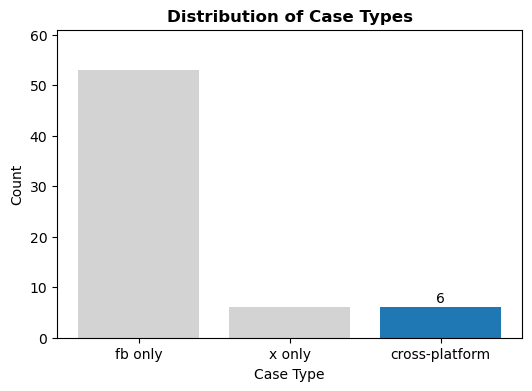

In [ ]:
case_counts = (
    df[["misinfo_case_id", "case_type"]]
    .drop_duplicates()
    ["case_type"]
    .value_counts()
)

plt.figure(figsize=(6,4))

bars = plt.bar(
    case_counts.index,
    case_counts.values,
    color=[
        plt.rcParams['axes.prop_cycle'].by_key()['color'][0]
        if c == "cross-platform"
        else "lightgray"
        for c in case_counts.index
    ]
)

# only label CROSS-PLATFORM bars
for i, bar in enumerate(bars):
    label = case_counts.index[i]

    if label == "cross-platform":
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.3,
            int(height),
            ha='center',
            va='bottom'
        )

plt.title("Distribution of Case Types", weight="bold")
plt.xlabel("Case Type")
plt.ylabel("Count")

plt.ylim(0, max(case_counts.values) * 1.15)

plt.show()

> Among the identified misinformation cases, only six were observed on both Facebook and X, indicating that **most cases remained confined to a single platform** within the collected dataset.

### Direction of Cross-Platform Propagation
> This visualization summarizes the observed direction of misinformation migration by identifying whether each cross-platform case first appeared on Facebook or on X.

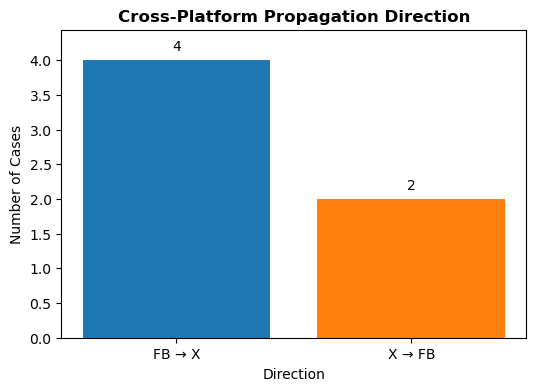

In [ ]:
direction_counts = migration_table["direction"].value_counts()

plt.figure(figsize=(6,4))

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

bars = plt.bar(
    direction_counts.index,
    direction_counts.values,
    color=colors[:len(direction_counts)]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.1,
        int(height),
        ha='center',
        va='bottom'
    )

plt.title("Cross-Platform Propagation Direction", weight="bold")
plt.xlabel("Direction")
plt.ylabel("Number of Cases")
plt.ylim(0, max(direction_counts.values) * 1.11)

plt.show()

> Most cross-platform cases originated on Facebook before appearing on X, suggesting that **Facebook served more frequently as the initial source of observed cross-platform misinformation diffusion**.

### Cross-Platform Migration Time

> This visualization presents the average time required for misinformation to migrate between Facebook and X based on the earliest observed occurrence of each cross-platform case.

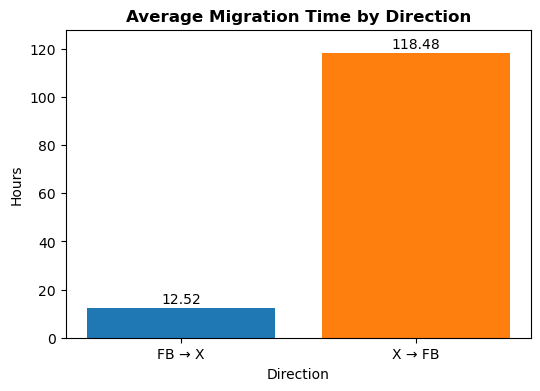

In [ ]:
avg_migration = (
    migration_table
    .groupby("direction")["migration_hours"]
    .mean()
)

plt.figure(figsize=(6,4))

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

bars = plt.bar(
    avg_migration.index,
    avg_migration.values,
    color=colors[:len(avg_migration)]
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.2f}",
        ha='center',
        va='bottom'
    )

plt.title("Average Migration Time by Direction", weight="bold")
plt.xlabel("Direction")
plt.ylabel("Hours")

plt.ylim(0, max(avg_migration.values) * 1.08)

plt.show()

> The average migration time indicates that **misinformation spread from Facebook to X more quickly than from X to Facebook** among the observed cross-platform cases.

---

## 5. Clustering Model Development

> This section groups misinformation diffusion cases based on their amplification characteristics to identify common propagation patterns. The computed amplification metrics serve as the feature set for clustering, enabling cases with similar structural and temporal diffusion behaviors to be grouped together. Multiple clustering algorithms are evaluated, and the most appropriate model is selected using internal clustering validation metrics.

> Prior to clustering, the amplification metrics are standardized to place all features on a common scale. Standardization prevents variables with larger numerical ranges from disproportionately influencing the distance calculations used by the clustering algorithms.

In [ ]:
# standardization

labels_df = metrics_df[['misinfo_case_id', 'platform', 'candidate_category']]
numeric_df = metrics_df.select_dtypes(include=['number'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

X_scaled = pd.DataFrame(X_scaled, columns=numeric_df.columns, index=metrics_df.index)
X_scaled_with_labels = pd.concat([labels_df, X_scaled], axis=1)

### K-means++ Clustering

> The K-means algorithm is first applied to partition the misinformation cases into groups based on their standardized amplification metrics. The optimal number of clusters is determined using the Elbow Method and subsequently evaluated using internal clustering validation metrics.

> The Elbow Method is used to examine the within-cluster sum of squares across different values of *k* to identify a suitable number of clusters.

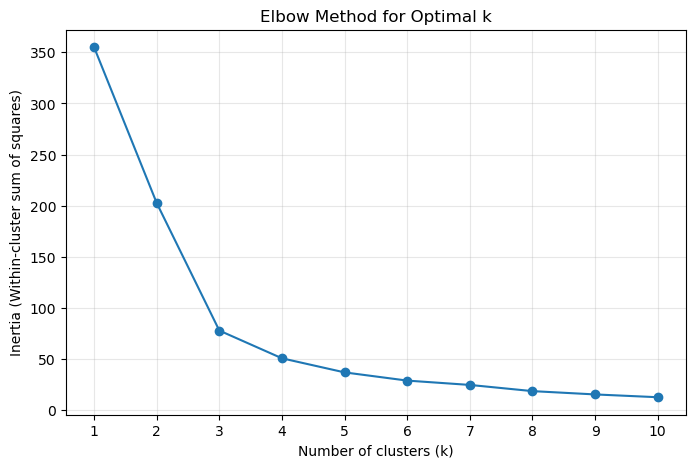

In [ ]:
# selection of possible k

k_values = range(1, 11)
inertia = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker='o')
plt.xticks(k_values)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (Within-cluster sum of squares)")
plt.title("Elbow Method for Optimal k")
plt.grid(alpha=0.3)
plt.show()

> Candidate values of *k* are then evaluated using the Silhouette Score, Calinski–Harabasz Index, and Davies–Bouldin Index to determine the most appropriate clustering solution.

In [ ]:
# selection of optimal k

results = []

for k in [3, 4, 5, 6]:
    kmeans = KMeans(n_clusters=k, init='k-means++')
    labels = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)

    results.append({
        "k": k,
        "Silhouette": sil,
        "Calinski-Harabasz": ch,
        "Davies-Bouldin": db,
    })

pd.DataFrame(results)

,k,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,3,0.659039,121.313240,0.454848
1,4,0.452053,133.314631,0.640783
2,5,0.449619,140.316262,0.683103
3,6,0.443199,139.311296,0.774260


In [ ]:
k = 3 # optimal k

> After selecting the optimal number of clusters, a grid search is performed over multiple initialization and convergence parameters to identify the configuration that produces the best overall clustering performance.

In [ ]:
param_grid = {
    'n_init': [10, 50, 100],
    'max_iter': [300, 500, 1000],
    'tol': [1e-3, 1e-4, 1e-5]
}

results = []

for n_init, max_iter, tol in itertools.product(param_grid['n_init'],
                                               param_grid['max_iter'],
                                               param_grid['tol']):

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=n_init,
        max_iter=max_iter,
        tol=tol,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)

    results.append({
        'n_init': n_init,
        'max_iter': max_iter,
        'tol': tol,
        'Silhouette': sil,
        'Davies-Bouldin': db,
        'Calinski-Harabasz': ch
    })

metrics_df = pd.DataFrame(results)

metrics_df['Silhouette_rank'] = metrics_df['Silhouette'].rank(ascending=False)
metrics_df['CH_rank'] = metrics_df['Calinski-Harabasz'].rank(ascending=False)
metrics_df['DB_rank'] = metrics_df['Davies-Bouldin'].rank(ascending=True)

metrics_df['Total_rank'] = (
    metrics_df['Silhouette_rank'] +
    metrics_df['CH_rank'] +
    metrics_df['DB_rank']
)

best_row = metrics_df.loc[metrics_df['Total_rank'].idxmin()]

best_row[['n_init','max_iter','tol']]

n_init       10.000
max_iter    300.000
tol           0.001
Name: 0, dtype: float64

> The best-performing parameter combination is used to train the final K-Means model, and the resulting cluster assignments are appended to the standardized dataset.

In [ ]:
kmeans = KMeans(
    n_clusters=k,
    init='k-means++',
    n_init=int(best_row['n_init']),
    max_iter=int(best_row['max_iter']),
    tol=float(best_row['tol']),
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

X_scaled_with_labels['kmeans_cluster'] = clusters

In [ ]:
sil = silhouette_score(X_scaled, clusters)
db = davies_bouldin_score(X_scaled, clusters)
ch = calinski_harabasz_score(X_scaled, clusters)

pd.DataFrame({
    "Metric": ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz"],
    "Value": [sil, db, ch]
})

,Metric,Value
0,Silhouette,0.659039
1,Davies-Bouldin,0.454848
2,Calinski-Harabasz,121.313240


### Agglomerative Hierarchical Clustering (Ward's Linkage)

> Ward's hierarchical clustering is evaluated as an alternative partitioning approach. This method iteratively merges observations by minimizing the increase in within-cluster variance, resulting in compact and homogeneous clusters.

> A dendrogram is first generated to examine the hierarchical structure of the data and identify plausible numbers of clusters.

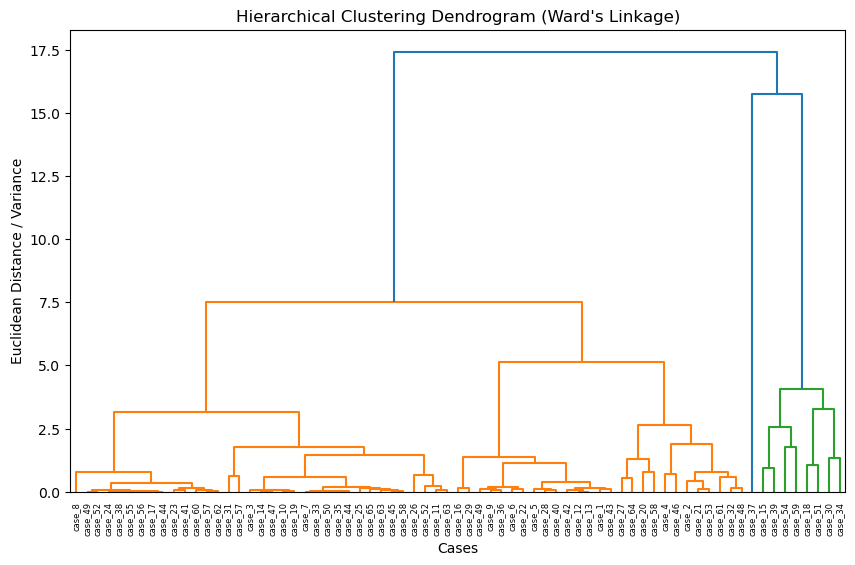

In [ ]:
# selection of possible k using dendogram

Z = linkage(X_scaled, method='ward', metric='euclidean')

plt.figure(figsize=(10, 6))
dendrogram(Z, labels=X_scaled_with_labels["misinfo_case_id"].values, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Ward's Linkage)")
plt.xlabel("Cases")
plt.ylabel("Euclidean Distance / Variance")
plt.show()

> Several candidate cluster solutions are evaluated using the same internal validation metrics employed for K-Means.

In [ ]:
# selection of optimal k

results = []

for k in [2, 3, 4, 5, 6]:
    agglo = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels = agglo.fit_predict(X_scaled)

    results.append({
        "k": k,
        "Silhouette": silhouette_score(X_scaled, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled, labels),
        "Davies-Bouldin": davies_bouldin_score(X_scaled, labels),
    })

pd.DataFrame(results)

,k,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,0.694640,51.428044,0.873370
1,3,0.680806,117.606976,0.412105
2,4,0.449968,132.023987,0.648924
3,5,0.444957,136.703698,0.607269
4,6,0.438285,141.284635,0.763454


In [ ]:
k_ward = 3

> Based on the evaluation results, the selected number of clusters is used to construct the final Ward hierarchical clustering model.

In [ ]:
ward_model = AgglomerativeClustering(
    n_clusters=k_ward,
    linkage='ward'
)

X_ward = X_scaled_with_labels[["size","reach","depth","width","speed"]].values
X_scaled_with_labels['wards_cluster'] = ward_model.fit_predict(X_ward)

In [ ]:
n_samples = len(X_ward)
iterations = n_samples - k_ward

print("Number of merge iterations:", iterations)

Number of merge iterations: 68


### Agglomerative Hierarchical Clustering (Average Linkage)

> Average linkage hierarchical clustering is also evaluated to determine whether an alternative linkage criterion produces more meaningful groupings of misinformation diffusion patterns.

> A dendrogram is generated to visualize the hierarchical relationships among the observations using average linkage.

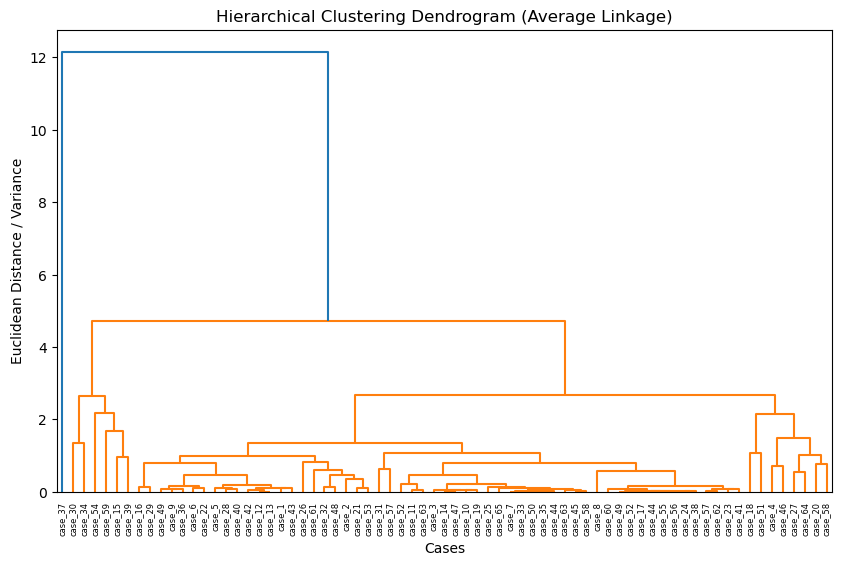

In [ ]:
# selection of possible k

Z = linkage(X_ward, method='average', metric='euclidean')

plt.figure(figsize=(10, 6))
dendrogram(Z, labels=X_scaled_with_labels["misinfo_case_id"].values, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Average Linkage)")
plt.xlabel("Cases")
plt.ylabel("Euclidean Distance / Variance")
plt.show()

> Different cluster solutions are evaluated using the internal clustering validation metrics.

In [ ]:
# selection of optimal k

results = []

for k in [2, 3, 4, 5, 6]:
    agglo = AgglomerativeClustering(
        n_clusters=k,
        linkage='average'
    )

    labels = agglo.fit_predict(X_ward)

    results.append({
        "k": k,
        "Silhouette": silhouette_score(X_ward, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_ward, labels),
        "Davies-Bouldin": davies_bouldin_score(X_ward, labels),
    })

pd.DataFrame(results)

,k,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,0.831749,46.410529,0.113158
1,3,0.661286,85.730328,0.394856
2,4,0.542036,114.294725,0.664339
3,5,0.540693,100.128475,0.643331
4,6,0.537540,84.842277,0.559161


In [ ]:
k_avg = 3

> Different distance metrics are subsequently evaluated to identify the configuration that provides the best clustering performance under the average linkage criterion.

In [ ]:
# Parameter grid for Average linkage
metrics = ['euclidean', 'manhattan', 'cityblock', 'l1',
           'l2', 'cosine', 'chebyshev', 'minkowski']

results = []

for metric in metrics:
    agglo = AgglomerativeClustering(
        n_clusters=k_avg,
        linkage='average',
        affinity=metric
    )

    labels = agglo.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)

    results.append({
        'linkage': 'average',
        'metric': metric,
        'Silhouette': sil,
        'Davies-Bouldin': db,
        'Calinski-Harabasz': ch
    })

# Convert to DataFrame
metrics_df = pd.DataFrame(results)

# Rank metrics
metrics_df['Silhouette_rank'] = metrics_df['Silhouette'].rank(ascending=False)
metrics_df['CH_rank'] = metrics_df['Calinski-Harabasz'].rank(ascending=False)
metrics_df['DB_rank'] = metrics_df['Davies-Bouldin'].rank(ascending=True)
metrics_df['Total_rank'] = metrics_df['Silhouette_rank'] + metrics_df['CH_rank'] + metrics_df['DB_rank']

# Pick the best
best_row = metrics_df.loc[metrics_df['Total_rank'].idxmin()]

print("Best hierarchical clustering parameters (average linkage):")
print(best_row[['linkage','metric','Silhouette','Davies-Bouldin','Calinski-Harabasz']])

Best hierarchical clustering parameters (average linkage):
linkage                 average
metric                chebyshev
Silhouette             0.680806
Davies-Bouldin         0.412105
Calinski-Harabasz    117.606976
Name: 6, dtype: object


> The best-performing distance metric is then used to construct the final average linkage clustering model.

In [ ]:
avg_model = AgglomerativeClustering(
    n_clusters=k_avg,
    linkage='average',
    metric=best_row['metric']
)

X_avg = X_scaled_with_labels[["size","reach","depth","width","speed"]].values
X_scaled_with_labels['avg_cluster'] = avg_model.fit_predict(X_avg)

### Model Comparison

> The clustering algorithms are compared using the Silhouette Score, Davies–Bouldin Index, and Calinski–Harabasz Index. These metrics assess cluster cohesion and separation, providing an objective basis for selecting the most appropriate clustering model for the study.

In [ ]:
model_comparison = pd.DataFrame({
    "Model": ["KMeans", "Ward", "Average"],
    "Silhouette": [
        silhouette_score(X_scaled, X_scaled_with_labels['kmeans_cluster']),
        silhouette_score(X_scaled, X_scaled_with_labels['wards_cluster']),
        silhouette_score(X_scaled, X_scaled_with_labels['avg_cluster']),
    ],
    "Davies-Bouldin": [
        davies_bouldin_score(X_scaled, X_scaled_with_labels['kmeans_cluster']),
        davies_bouldin_score(X_scaled, X_scaled_with_labels['wards_cluster']),
        davies_bouldin_score(X_scaled, X_scaled_with_labels['avg_cluster']),
    ],
    "Calinski-Harabasz": [
        calinski_harabasz_score(X_scaled, X_scaled_with_labels['kmeans_cluster']),
        calinski_harabasz_score(X_scaled, X_scaled_with_labels['wards_cluster']),
        calinski_harabasz_score(X_scaled, X_scaled_with_labels['avg_cluster']),
    ]
})

model_comparison

,Model,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,KMeans,0.659039,0.454848,121.313240
1,Ward,0.680806,0.412105,117.606976
2,Average,0.680806,0.412105,117.606976


> Ward's linkage is selected as the final clustering model because its variance-minimization objective produces compact and interpretable groups that align with the study's objective of identifying distinct misinformation amplification behaviors. Although Average linkage achieved comparable validation scores, Ward's method is generally more suitable for standardized continuous variables and offers greater robustness for this type of analysis.

---
## 6. Cluster Interpretation and Validation

> This section interprets the clustering results obtained from the selected Ward hierarchical clustering model. Multiple visualization techniques are employed to examine cluster characteristics, evaluate their separability, assess clustering stability, and identify the amplification behaviors represented by each cluster.

> The selected cluster assignments are consolidated with the standardized amplification metrics to create the final dataset used for visualization and interpretation.

In [ ]:
X_scaled_with_labels

,misinfo_case_id,platform,candidate_category,size,reach,depth,width,speed,kmeans_cluster,wards_cluster,avg_cluster
0,case_1,fb,elective local official,-0.573183,-0.155774,0.302840,-0.624319,-0.119792,1,0,2
1,case_2,fb,senator,0.022193,0.149745,0.302840,0.136105,-0.119639,1,0,2
2,case_3,fb,elective local official,-0.522971,-0.196408,-0.438596,-0.530107,-0.119800,1,0,2
3,case_4,fb,elective local official,0.562575,-0.220040,1.044276,0.607164,-0.119681,1,0,2
4,case_5,fb,senator,-0.465585,-0.229176,0.302840,-0.503189,-0.119793,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...
66,case_62,fb,member of the house of representatives,-0.601876,-0.226845,-1.180032,-0.637778,-0.119646,1,0,2
67,case_63,fb,elective local official,-0.640133,-0.233415,-0.438596,-0.694978,-0.119786,1,0,2
68,case_63,x,senator,-0.369942,-0.232377,-0.438596,-0.314766,-0.119696,1,0,2
69,case_64,fb,elective local official,0.550620,0.584056,-0.438596,0.960458,-0.119784,1,0,2


In [ ]:
df_with_cluster = X_scaled_with_labels.drop(columns=['kmeans_cluster', 'avg_cluster'])
df_with_cluster

,misinfo_case_id,platform,candidate_category,size,reach,depth,width,speed,wards_cluster
0,case_1,fb,elective local official,-0.573183,-0.155774,0.302840,-0.624319,-0.119792,0
1,case_2,fb,senator,0.022193,0.149745,0.302840,0.136105,-0.119639,0
2,case_3,fb,elective local official,-0.522971,-0.196408,-0.438596,-0.530107,-0.119800,0
3,case_4,fb,elective local official,0.562575,-0.220040,1.044276,0.607164,-0.119681,0
4,case_5,fb,senator,-0.465585,-0.229176,0.302840,-0.503189,-0.119793,0
...,...,...,...,...,...,...,...,...,...
66,case_62,fb,member of the house of representatives,-0.601876,-0.226845,-1.180032,-0.637778,-0.119646,0
67,case_63,fb,elective local official,-0.640133,-0.233415,-0.438596,-0.694978,-0.119786,0
68,case_63,x,senator,-0.369942,-0.232377,-0.438596,-0.314766,-0.119696,0
69,case_64,fb,elective local official,0.550620,0.584056,-0.438596,0.960458,-0.119784,0


### Parallel Coordinates Plot

> A parallel coordinates plot is generated to compare the standardized amplification metrics across clusters. This visualization highlights the overall feature profiles that distinguish one cluster from another.

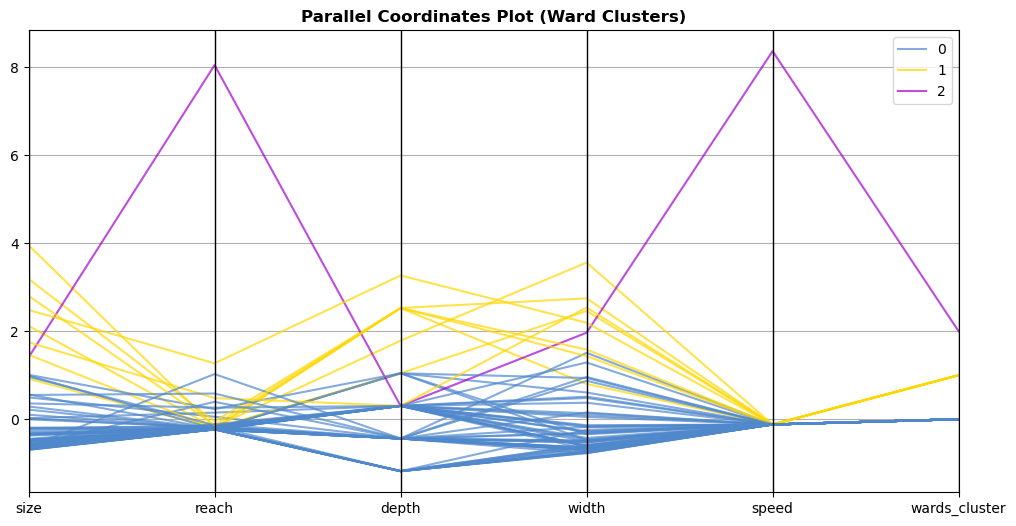

In [ ]:
from pandas.plotting import parallel_coordinates
import matplotlib.pyplot as plt

viz_df = df_with_cluster.select_dtypes(include=['number']).copy()
viz_df["Cluster"] = df_with_cluster["wards_cluster"]

plt.figure(figsize=(12,6))

parallel_coordinates(
    viz_df,
    class_column="Cluster",
    color=("#5088cc", "#ffd700", "#a300cf"),
    alpha=0.7
)

plt.title("Parallel Coordinates Plot (Ward Clusters)", weight="bold")
plt.show()

### Pairwise Feature Relationships

> A pairwise scatter plot matrix is generated to examine the relationships among the amplification metrics and evaluate the degree of overlap between the identified clusters.

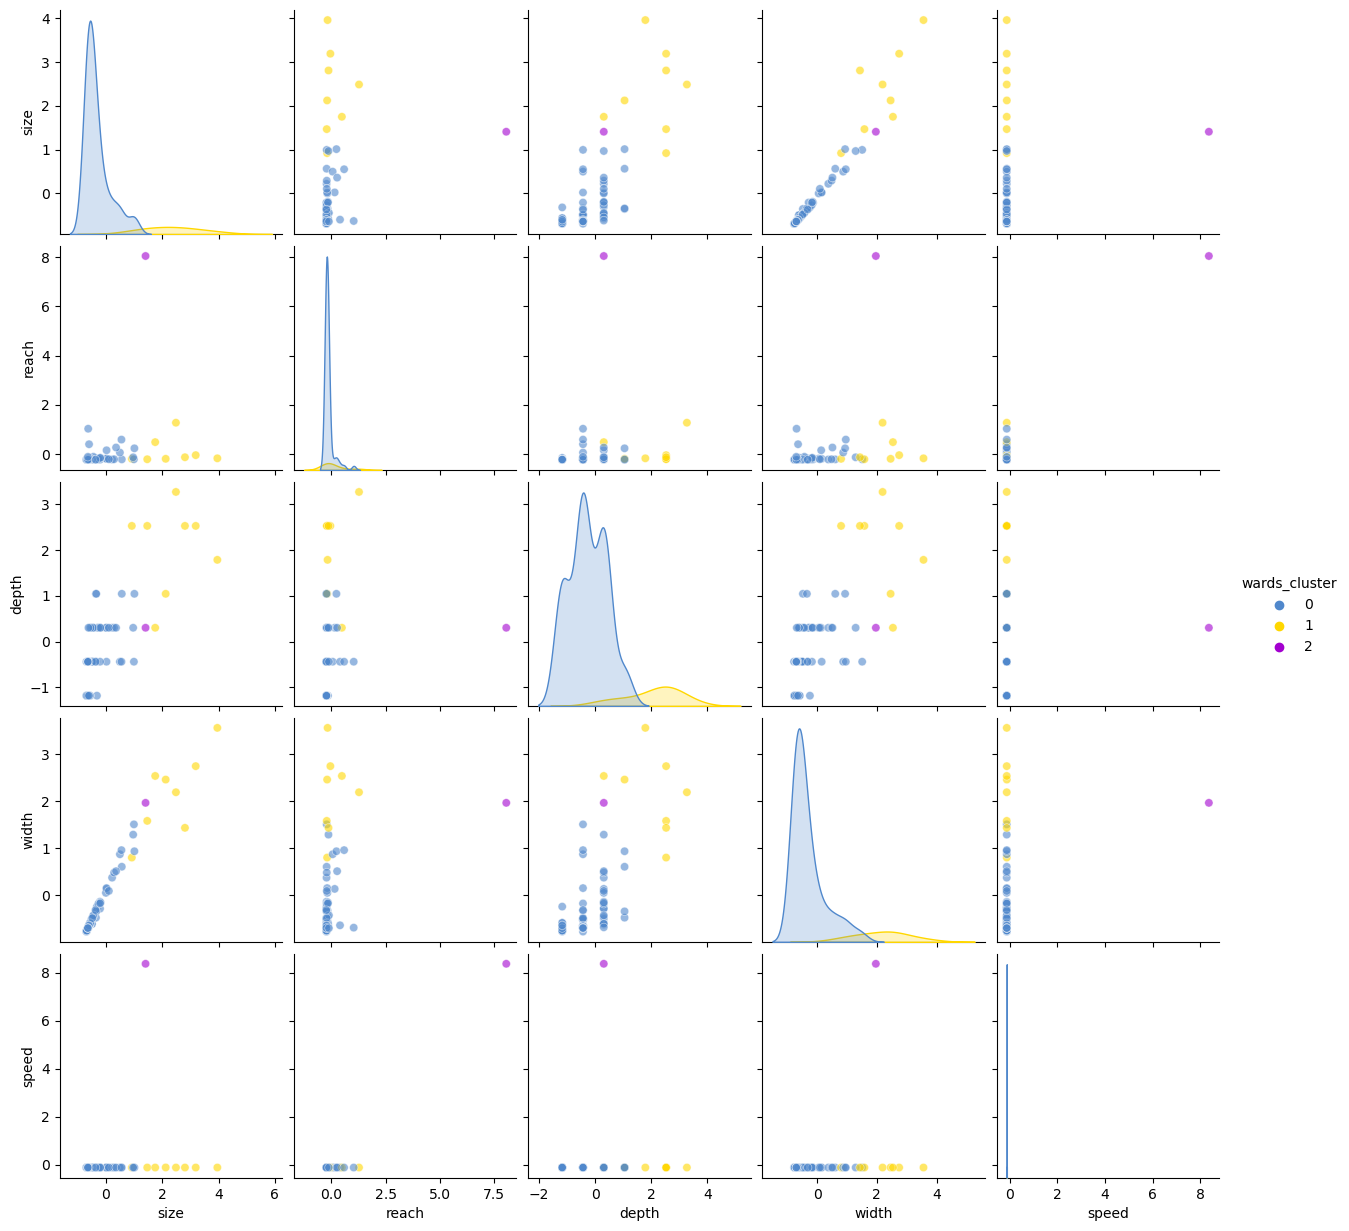

In [ ]:
palette = ["#5088cc", "#ffd700", "#a300cf"]

sns.pairplot(
    df_with_cluster[["size", "reach", "depth", "width", "speed", "wards_cluster"]],
    hue="wards_cluster",
    diag_kind="kde",
    plot_kws={"alpha": 0.6},
    palette=palette
)

plt.show()

### Principal Component Analysis (PCA)

> Principal Component Analysis (PCA) is applied to project the standardized amplification metrics into two dimensions. Although PCA is not used for clustering, it provides a visual representation of the overall cluster structure and separation.

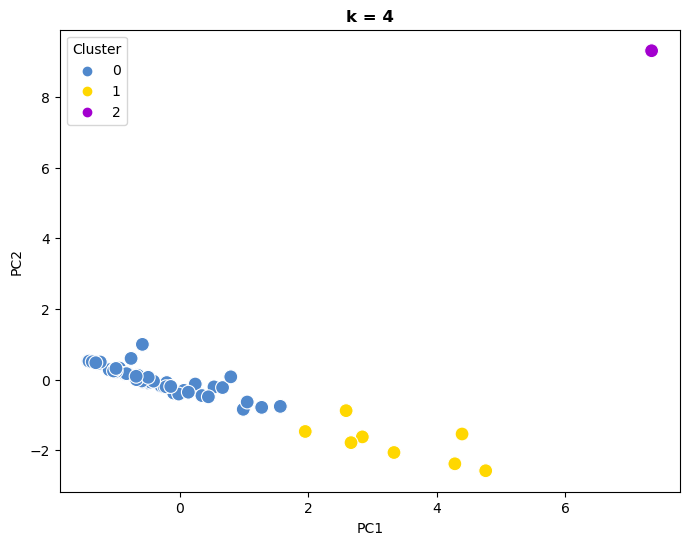

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

X_pca = PCA(n_components=2).fit_transform(
    df_with_cluster[["size","reach","depth","width","speed"]]
)

pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2"])
pca_df["Cluster"] = df_with_cluster["wards_cluster"]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette=palette,
    s=100
)

plt.title("k = 4", weight="bold")
plt.show()

### Clustering Stability Assessment

> The robustness of the selected clustering solution is evaluated using bootstrap resampling and repeated subsampling. These procedures examine whether similar cluster structures are preserved when the dataset is artificially perturbed or partially observed.

#### Bootstrap Resampling

> Bootstrap resampling repeatedly generates new datasets through sampling with replacement. The resulting cluster assignments are compared with the original clustering solution using the Adjusted Rand Index (ARI) to assess the sensitivity of the model to duplicated observations and changes in data distribution.

In [ ]:
from sklearn.utils import resample
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import AgglomerativeClustering
import numpy as np

In [ ]:
base_labels = df_with_cluster["wards_cluster"].values

scores = []

for i in range(100):
    X_boot = resample(
        df_with_cluster[["size","reach","depth","width","speed"]],
        replace=True,
        n_samples=len(df_with_cluster),
        random_state=i
    )

    model = AgglomerativeClustering(n_clusters=3, linkage="ward")
    boot_labels = model.fit_predict(X_boot)

    score = adjusted_rand_score(base_labels, boot_labels)
    scores.append(score)

np.mean(scores), np.std(scores)

(0.007163606234134994, 0.08485291178904907)

In [ ]:
X_boot = resample(X,
                  replace=True,
                  n_samples=len(X),
                  random_state=i)

labels_boot = model.fit_predict(X_boot)

In [ ]:
mean_sil = np.mean(silhouette_score(X_scaled, X_scaled_with_labels['wards_cluster']))
std_sil = np.std(silhouette_score(X_scaled, X_scaled_with_labels['wards_cluster']))

In [ ]:
mean_sil

0.6808064682341647

In [ ]:
std_sil

0.0

Clustering shows very low stability under bootstrap resampling, meaning:
- when the dataset is resampled with replacement (duplicates + missing cases),
- the cluster assignments change almost completely,
- indicating that the model is highly sensitive to data distortion and repeated observations.

> 🔴 **The clustering structure is not preserved when the dataset distribution is artificially reshaped through duplication.** This suggests that Ward clustering is sensitive to frequency bias and artificial weighting of observations.

#### Repeated Subsampling

> Repeated subsampling evaluates clustering stability by repeatedly fitting the model on randomly selected subsets of the dataset. The resulting cluster assignments are compared with those obtained from the corresponding subset of the original data using the Adjusted Rand Index.

In [ ]:
from sklearn.model_selection import ShuffleSplit

In [ ]:
base_labels = df_with_cluster["wards_cluster"].values

scores = []

X = df_with_cluster[["size","reach","depth","width","speed"]]

rs = ShuffleSplit(
    n_splits=100,
    test_size=0.3,
    random_state=42
)

for i, (train_idx, _) in enumerate(rs.split(X)):

    X_subsample = X.iloc[train_idx]

    model = AgglomerativeClustering(
        n_clusters=3,
        linkage="ward"
    )

    subsample_labels = model.fit_predict(X_subsample)

    base_subset = base_labels[train_idx]

    score = adjusted_rand_score(base_subset, subsample_labels)

    scores.append(score)

np.mean(scores), np.std(scores)

(0.710165919291533, 0.2972512955036502)

Cluster have stronger stability under repeated subsampling, meaning:
- when random subsets of the data are removed,
- the cluster structure remains largely consistent,
- indicating that the model captures a real underlying pattern in the data.

> 🟢 **The clustering solution remains relatively stable when only portions of the dataset are observed, suggesting that the identified groups reflect a consistent structural pattern in misinformation propagation behavior.**

#### Overall Stability Assessment

> Taken together, the bootstrap resampling and repeated subsampling results suggest that the Ward clustering model captures meaningful amplification patterns while remaining sensitive to changes in data distribution. Although the precise cluster boundaries may shift under substantial distributional distortion, the broader structural relationships among misinformation cases remain largely consistent.

### Cluster Characteristics

> The identified clusters are summarized using the mean standardized amplification metrics to examine the diffusion characteristics represented by each group.

In [ ]:
# summary of clusters

wards_clusters = df_with_cluster.drop(columns=['misinfo_case_id', 'platform', 'candidate_category'], errors='ignore')

cluster_summary = wards_clusters.groupby('wards_cluster')[wards_clusters.columns].mean()
print(cluster_summary)

                   size     reach     depth     width     speed  wards_cluster
wards_cluster                                                                 
0             -0.324126 -0.142465 -0.271175 -0.311076 -0.119554            0.0
1              2.336151  0.097799  2.063751  2.165023 -0.119284            1.0
2              1.406623  8.050441  0.302840  1.966505  8.366598            2.0


> The misinformation cases belonging to each cluster are listed to facilitate qualitative interpretation of the identified amplification patterns.

In [ ]:
# content of clusters

import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

for cluster in range(1):
    print(f"\nCluster {cluster} contains:")
    print(df_with_cluster[df_with_cluster['wards_cluster'] == cluster][['misinfo_case_id','platform', 'candidate_category']])


Cluster 0 contains:
   misinfo_case_id platform                      candidate_category
0           case_1       fb                 elective local official
1           case_2       fb                                 senator
2           case_3       fb                 elective local official
3           case_4       fb                 elective local official
4           case_5       fb                                 senator
5           case_6       fb  member of the house of representatives
6           case_7       fb                 elective local official
7           case_8       fb                 elective local official
8           case_9       fb                 elective local official
9          case_10       fb                 elective local official
10         case_11       fb                                 senator
11         case_12       fb                 elective local official
12         case_13       fb                 elective local official
13         case_14       fb

In [ ]:
# content of clusters

for cluster in range(3):
    print(f"\nCluster {cluster} contains:")
    print(df_with_cluster[df_with_cluster['wards_cluster'] == cluster][['misinfo_case_id','platform', 'candidate_category']])


Cluster 0 contains:
   misinfo_case_id platform                      candidate_category
0           case_1       fb                 elective local official
1           case_2       fb                                 senator
2           case_3       fb                 elective local official
3           case_4       fb                 elective local official
4           case_5       fb                                 senator
..             ...      ...                                     ...
66         case_62       fb  member of the house of representatives
67         case_63       fb                 elective local official
68         case_63        x                                 senator
69         case_64       fb                 elective local official
70         case_65       fb                 elective local official

[62 rows x 3 columns]

Cluster 1 contains:
   misinfo_case_id platform       candidate_category
14         case_15       fb  elective local official
17         ca

> The distribution of Facebook and X cases across the identified clusters is examined to determine whether amplification patterns differ between platforms.

In [ ]:
# platform count per cluster

platform_per_cluster = df_with_cluster.groupby(["wards_cluster", "platform"]).size().reset_index(name="count")
platform_per_cluster

,wards_cluster,platform,count
0,0,fb,50
1,0,x,12
2,1,fb,8
3,2,fb,1


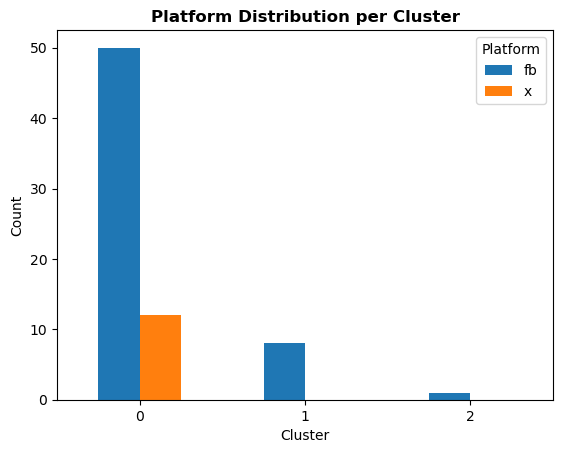

In [ ]:
platform_per_cluster = (
    X_scaled_with_labels
    .groupby(["wards_cluster", "platform"])
    .size()
    .unstack(fill_value=0)
)

platform_per_cluster.plot(kind="bar")

plt.title("Platform Distribution per Cluster", weight='bold')
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Platform", loc="upper right")

plt.show()

> Similarly, the distribution of candidate categories across clusters is analyzed to identify potential differences in amplification behavior among the candidate groups represented in the dataset.

In [ ]:
# candidate count per cluster

candidate_per_cluster = df_with_cluster.groupby(["wards_cluster", "candidate_category"]).size().reset_index(name="count")
candidate_per_cluster

,wards_cluster,candidate_category,count
0,0,elective local official,35
1,0,member of the house of representatives,7
2,0,party-list,4
3,0,senator,16
4,1,elective local official,6
5,1,senator,2
6,2,senator,1


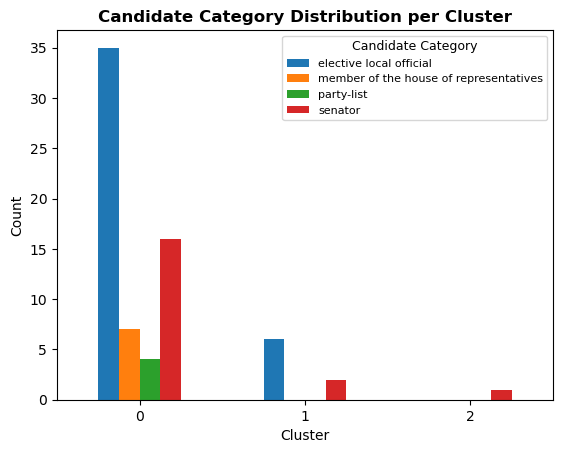

In [ ]:
candidate_per_cluster = (
    df_with_cluster
    .groupby(["wards_cluster", "candidate_category"])
    .size()
    .unstack(fill_value=0)
)

candidate_per_cluster.plot(kind="bar")

plt.title("Candidate Category Distribution per Cluster", weight='bold')
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Candidate Category", loc="upper right", fontsize=8, title_fontsize=9)

plt.show()

## 7. Exploratory Clustering Analysis

> Although the primary clustering solution consists of three clusters, an additional exploratory analysis using five clusters is performed to investigate whether finer-grained amplification patterns emerge beyond the selected model. This analysis is intended solely for exploratory purposes and is not used in the study's primary findings.

> Ward hierarchical clustering is repeated using five clusters, followed by multiple visualization techniques to examine the resulting amplification patterns.

In [ ]:
k_explo = 5

In [ ]:
ward_explo = AgglomerativeClustering(
    n_clusters=k_explo,
    linkage='ward'
)

X_ward_explo = df_with_cluster[["size","reach","depth","width","speed"]].values
df_with_cluster['wards_cluster (k=5)'] = ward_explo.fit_predict(X_ward_explo)

In [ ]:
df_with_cluster

,misinfo_case_id,platform,candidate_category,size,reach,depth,width,speed,wards_cluster,wards_cluster (k=5)
0,case_1,fb,elective local official,-0.573183,-0.155774,0.302840,-0.624319,-0.119792,0,4
1,case_2,fb,senator,0.022193,0.149745,0.302840,0.136105,-0.119639,0,3
2,case_3,fb,elective local official,-0.522971,-0.196408,-0.438596,-0.530107,-0.119800,0,1
3,case_4,fb,elective local official,0.562575,-0.220040,1.044276,0.607164,-0.119681,0,3
4,case_5,fb,senator,-0.465585,-0.229176,0.302840,-0.503189,-0.119793,0,4
...,...,...,...,...,...,...,...,...,...,...
66,case_62,fb,member of the house of representatives,-0.601876,-0.226845,-1.180032,-0.637778,-0.119646,0,1
67,case_63,fb,elective local official,-0.640133,-0.233415,-0.438596,-0.694978,-0.119786,0,1
68,case_63,x,senator,-0.369942,-0.232377,-0.438596,-0.314766,-0.119696,0,1
69,case_64,fb,elective local official,0.550620,0.584056,-0.438596,0.960458,-0.119784,0,3


> A pairwise feature visualization is generated to examine the relationships among the exploratory clusters.

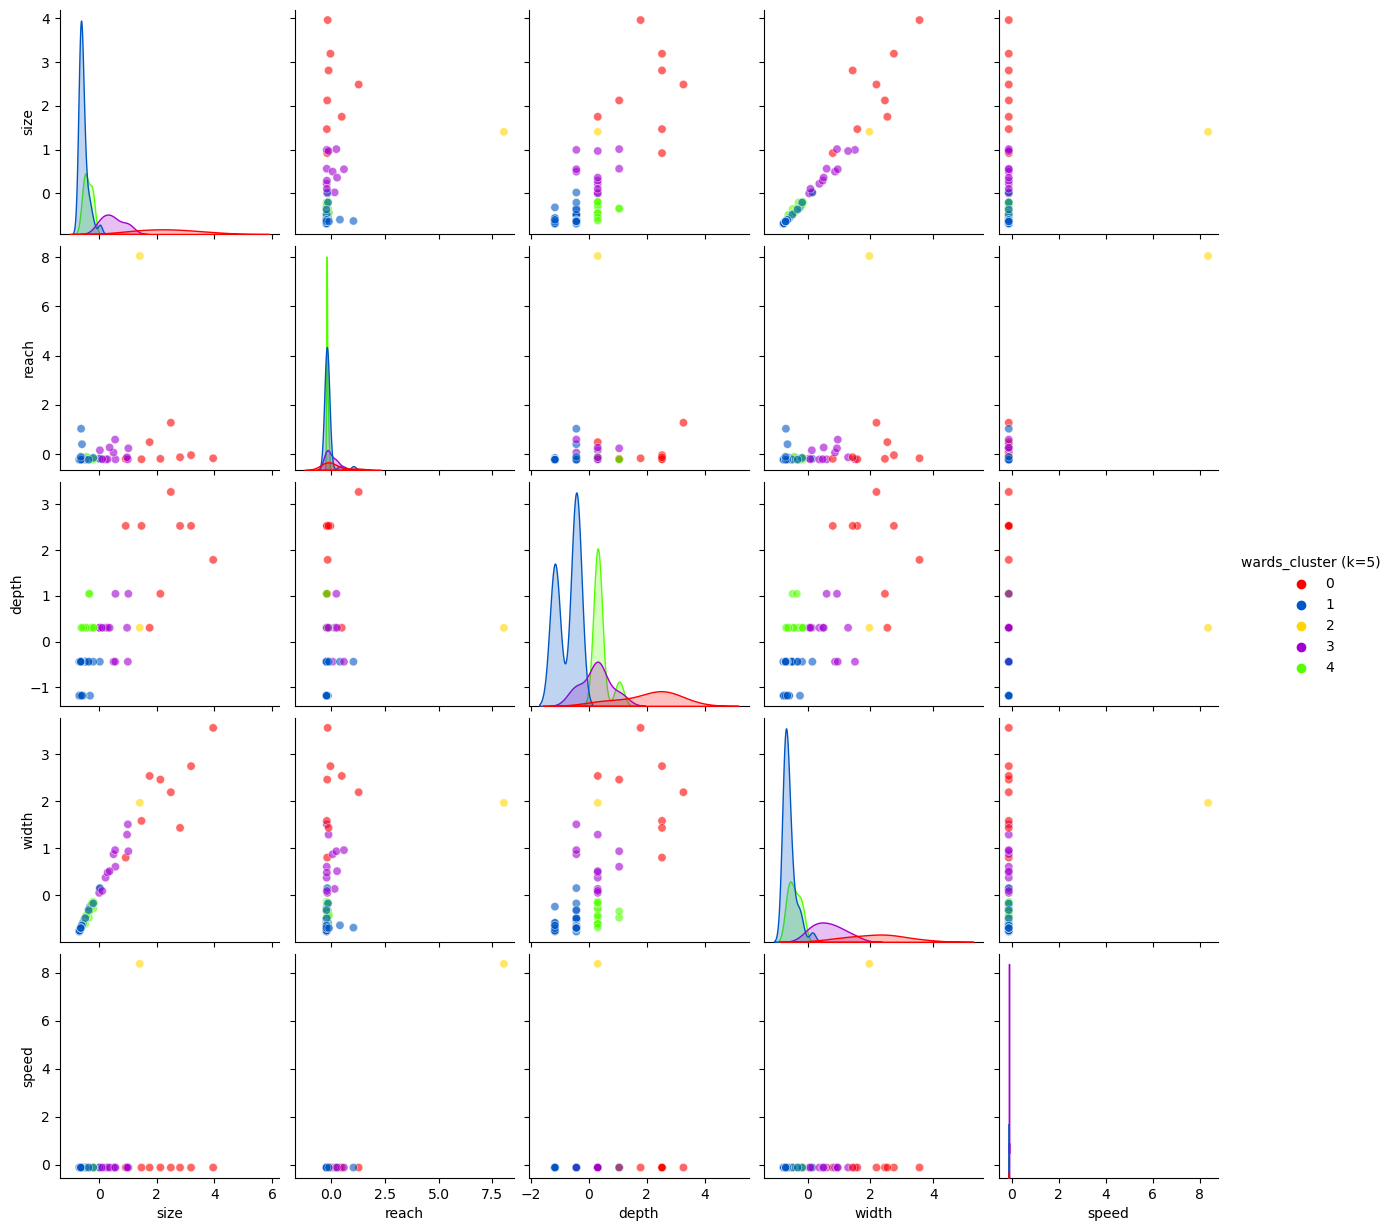

In [ ]:
sns.pairplot(
    df_with_cluster[["size", "reach", "depth", "width", "speed", "wards_cluster (k=5)"]],
    hue="wards_cluster (k=5)",
    diag_kind="kde",
    plot_kws={"alpha": 0.6},
    palette="prism"
)

plt.show()

> Parallel coordinates are used to compare the standardized amplification profiles of the exploratory clusters.

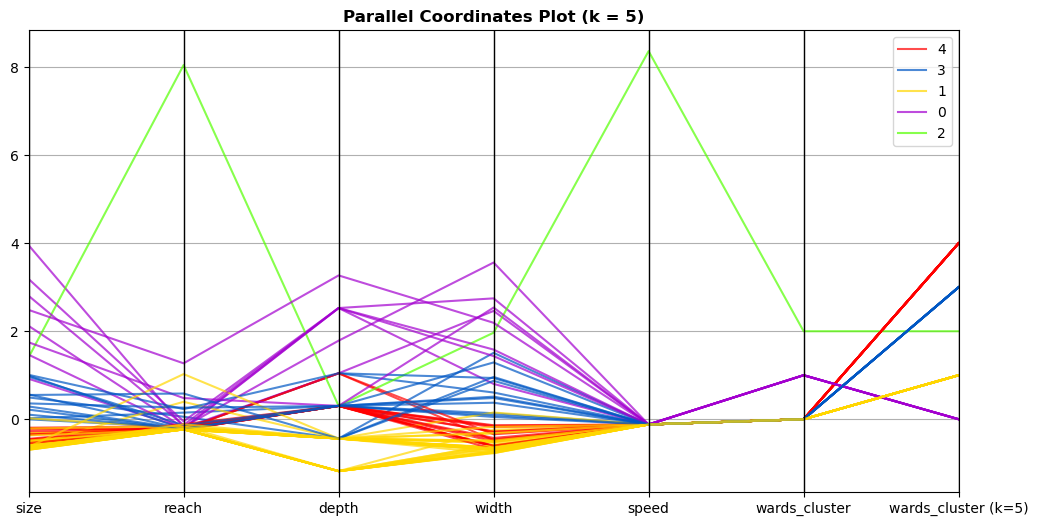

In [ ]:
viz_df_exp = df_with_cluster.select_dtypes(include=['number']).copy()
viz_df_exp["Cluster"] = df_with_cluster["wards_cluster (k=5)"]

plt.figure(figsize=(12,6))

parallel_coordinates(
    viz_df_exp,
    class_column="Cluster",
    colormap="prism",
    alpha=0.7
)

plt.title("Parallel Coordinates Plot (k = 5)", weight="bold")
plt.show()

> A two-dimensional PCA projection provides an overview of the separation among the exploratory clusters.

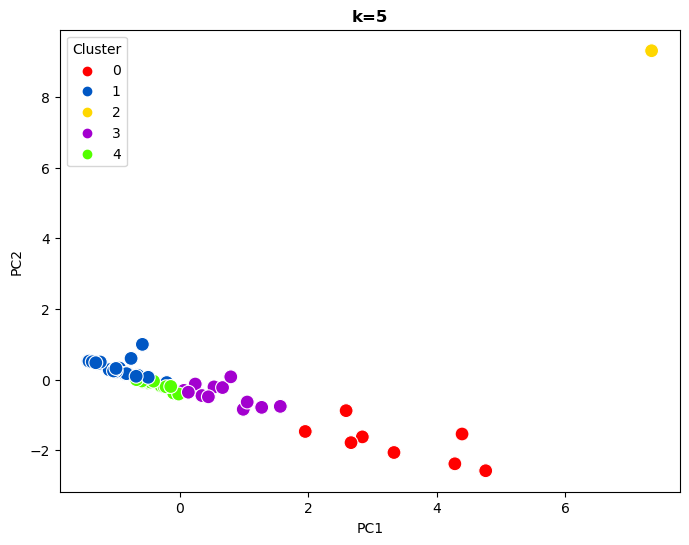

In [ ]:
X_pca = PCA(n_components=2).fit_transform(
    df_with_cluster[["size","reach","depth","width","speed"]]
)

pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2"])
pca_df["Cluster"] = df_with_cluster["wards_cluster (k=5)"]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="prism",
    s=100
)

plt.title("k=5", weight='bold')
plt.show()

>The exploratory clusters are summarized using the mean standardized amplification metrics to facilitate comparison with the primary clustering solution.

In [ ]:
wards_clusters = df_with_cluster.drop(columns=['misinfo_case_id', 'platform', 'candidate_category', 'wards_cluster'], errors='ignore')

cluster_summary = wards_clusters.groupby('wards_cluster (k=5)')[wards_clusters.columns].mean()
print(cluster_summary)

                         size     reach     depth     width     speed  \
wards_cluster (k=5)                                                     
0                    2.336151  0.097799  2.063751  2.165023 -0.119284   
1                   -0.561706 -0.161158 -0.735170 -0.592883 -0.119478   
2                    1.406623  8.050441  0.302840  1.966505  8.366598   
3                    0.464143 -0.010852  0.241054  0.652307 -0.119769   
4                   -0.400389 -0.204139  0.401698 -0.424231 -0.119558   

                     wards_cluster (k=5)  
wards_cluster (k=5)                       
0                                    0.0  
1                                    1.0  
2                                    2.0  
3                                    3.0  
4                                    4.0  


---
## 8. Error Analysis

> This section investigates whether the primary clusters contain additional internal structure by performing hierarchical subclustering within selected clusters. The objective is to determine whether further partitioning produces meaningful subgroups or whether the primary clustering solution already provides an appropriate level of granularity.

### Cluster 1: Deep and Expansive Cascades

> The high-amplification cluster is further analyzed to determine whether distinct propagation behaviors exist within this group.

In [ ]:
cluster_high = df_with_cluster[df_with_cluster["wards_cluster"] == 1].copy()
X_high = cluster_high[["size","reach","depth","width","speed"]]

>A secondary dendrogram is generated to visualize the hierarchical structure of the cases contained within the cluster.

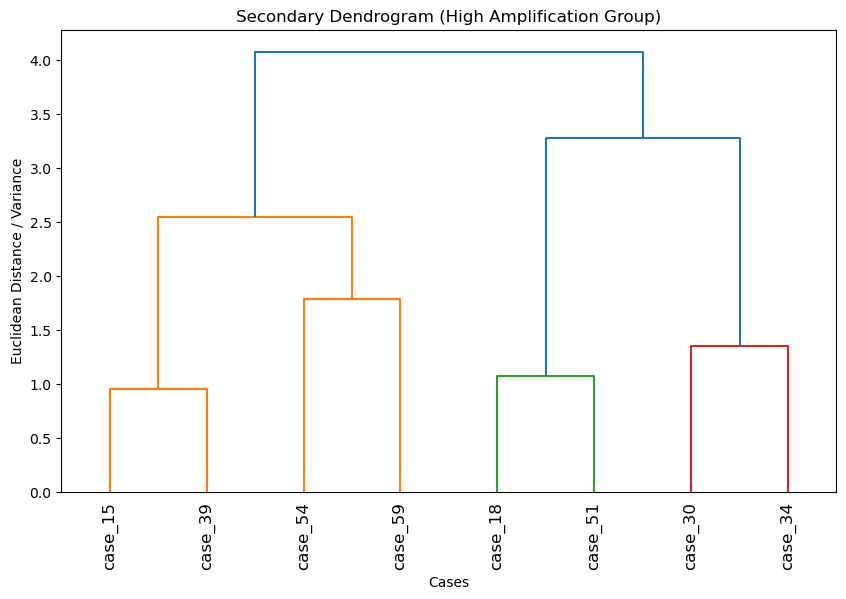

In [ ]:
Z_high = linkage(X_high, method='ward', metric='euclidean')

plt.figure(figsize=(10, 6))

dendrogram(
    Z_high,
    labels=cluster_high["misinfo_case_id"].values,
    leaf_rotation=90
)

plt.title("Secondary Dendrogram (High Amplification Group)")
plt.xlabel("Cases")
plt.ylabel("Euclidean Distance / Variance")

plt.show()

> Several candidate subcluster solutions are evaluated using the same internal clustering validation metrics employed in the primary clustering analysis.

In [ ]:
# selection of optimal k

results = []

for k in [2, 3, 4, 5]:

    agglo = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    # IMPORTANT: fit and predict INSIDE loop
    labels = agglo.fit_predict(X_high)

    # SAFETY CHECK: skip invalid cases
    if len(np.unique(labels)) < 2:
        print(f"Skipping k={k} (only 1 cluster formed)")
        continue

    # compute metrics
    sil = silhouette_score(X_high, labels)
    ch = calinski_harabasz_score(X_high, labels)
    db = davies_bouldin_score(X_high, labels)

    results.append({
        "k": k,
        "Silhouette": sil,
        "Calinski-Harabasz": ch,
        "Davies-Bouldin": db,
    })

df_results = pd.DataFrame(results)
df_results

,k,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,0.251547,4.111075,1.165678
1,3,0.346909,5.053128,0.729456
2,4,0.362626,6.375619,0.744668
3,5,0.293925,7.156636,0.422302


> The selected number of subclusters is used to construct the final hierarchical subclustering model for the high-amplification group.

In [ ]:
k_cluster_high = 5

In [ ]:
cluster_high_wards = AgglomerativeClustering(
    n_clusters=k_cluster_high,
    linkage='ward'
)

cluster_high["sub_cluster_high"] = cluster_high_wards.fit_predict(X_high.values)

> The resulting subclusters are visualized using PCA, pairwise feature plots, and parallel coordinates to examine whether meaningful internal amplification patterns are present.

In [ ]:
viz_high = cluster_high.copy()
viz_high["sub_cluster_high"] = cluster_high["sub_cluster_high"]

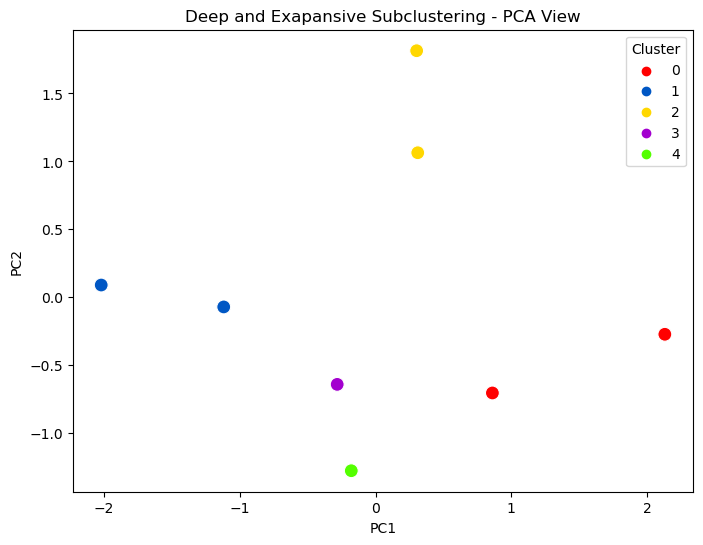

In [ ]:
features = ["size","reach","depth","width","speed"]
X_pca = PCA(n_components=2).fit_transform(viz_high[features])

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = viz_high["sub_cluster_high"].values

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette="prism", s=100)

plt.title("Deep and Exapansive Subclustering - PCA View")
plt.show()

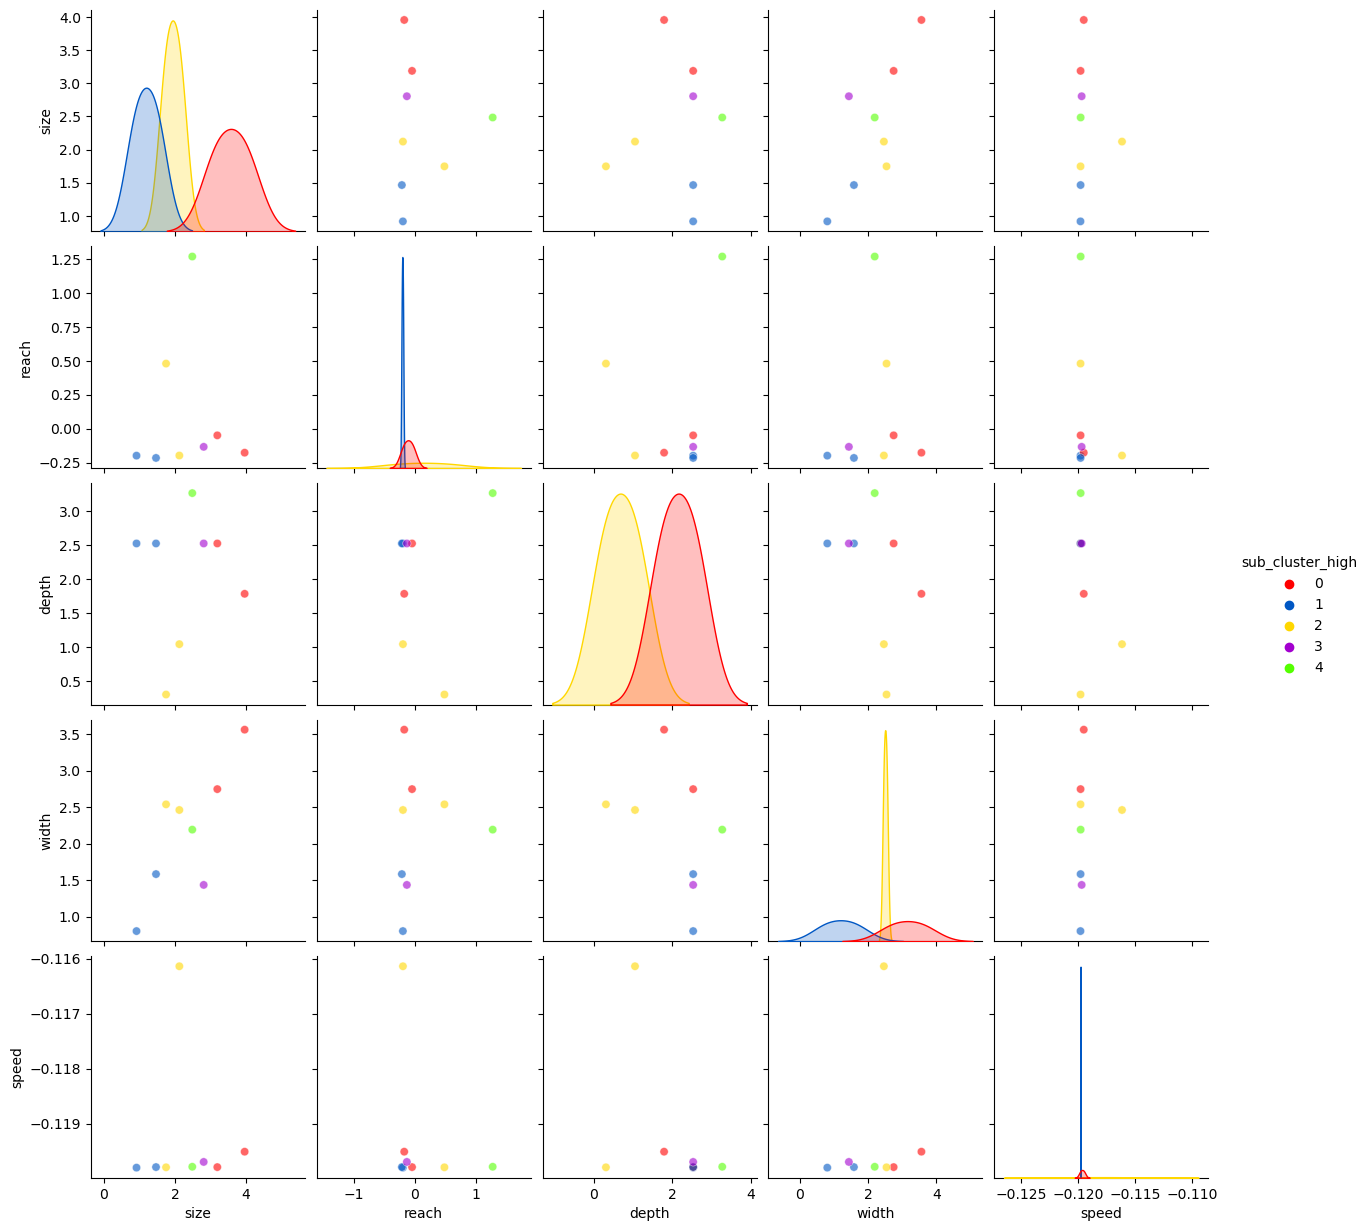

In [ ]:
sns.pairplot(
    viz_high[features + ["sub_cluster_high"]],
    hue="sub_cluster_high",
    palette="prism",
    diag_kind="kde",
    plot_kws={"alpha": 0.6}
)

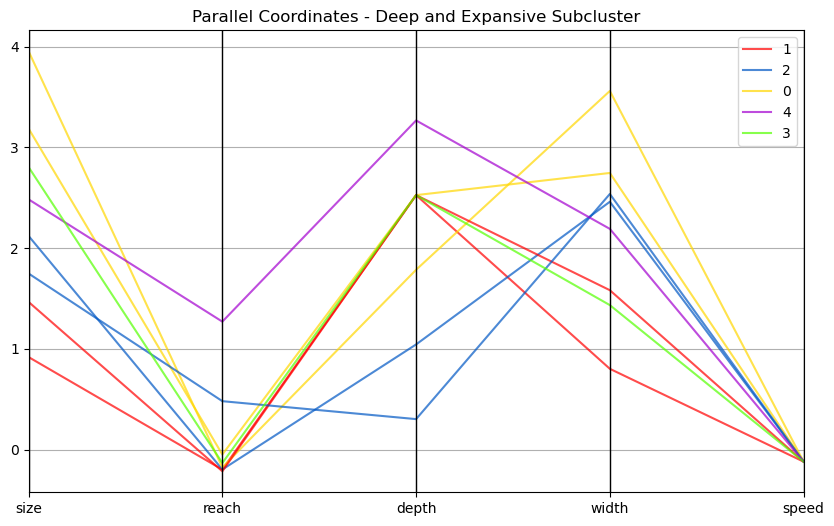

In [ ]:
plot_df = viz_high[features + ["sub_cluster_high"]].copy()

plt.figure(figsize=(10,6))

parallel_coordinates(
    plot_df,
    class_column="sub_cluster_high",
    colormap="prism",
    alpha=0.7
)

plt.title("Parallel Coordinates - Deep and Expansive Subcluster")
plt.show()

### Cluster 0: Weakly Amplified Cascades

> The low-amplification cluster is similarly examined to determine whether additional subgroups can be identified.

In [ ]:
cluster_low = df_with_cluster[df_with_cluster["wards_cluster"] == 0].copy()
X_low = cluster_low[["size","reach","depth","width","speed"]]

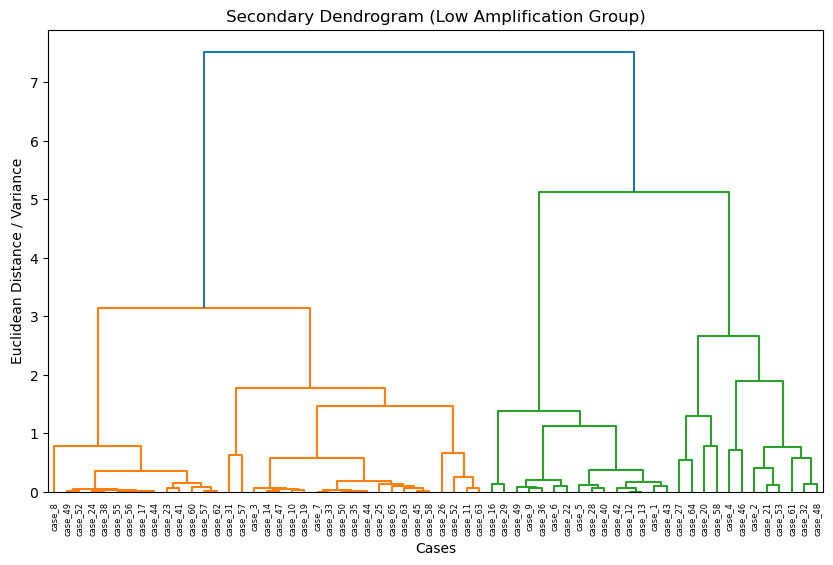

In [ ]:
Z_low = linkage(X_low, method='ward', metric='euclidean')

plt.figure(figsize=(10, 6))

dendrogram(
    Z_low,
    labels=cluster_low["misinfo_case_id"].values,
    leaf_rotation=90
)

plt.title("Secondary Dendrogram (Low Amplification Group)")
plt.xlabel("Cases")
plt.ylabel("Euclidean Distance / Variance")

plt.show()

In [ ]:
# selection of optimal k

results = []

for k in [2, 3, 4, 5]:

    agglo = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    # IMPORTANT: fit and predict INSIDE loop
    labels = agglo.fit_predict(X_low)

    # SAFETY CHECK: skip invalid cases
    if len(np.unique(labels)) < 2:
        print(f"Skipping k={k} (only 1 cluster formed)")
        continue

    # compute metrics
    sil = silhouette_score(X_low, labels)
    ch = calinski_harabasz_score(X_low, labels)
    db = davies_bouldin_score(X_low, labels)

    results.append({
        "k": k,
        "Silhouette": sil,
        "Calinski-Harabasz": ch,
        "Davies-Bouldin": db,
    })

df_results = pd.DataFrame(results)
df_results

,k,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,0.468611,54.858689,0.911684
1,3,0.474795,68.704304,0.713851
2,4,0.538794,69.865222,0.679888
3,5,0.547438,76.551237,0.766601


In [ ]:
k_wards_low = 4

In [ ]:
cluster_low_wards = AgglomerativeClustering(
    n_clusters=k_wards_low,
    linkage='ward'
)

cluster_low["sub_cluster_low"] = cluster_low_wards.fit_predict(X_low.values)

In [ ]:
viz_low = cluster_low.copy()
viz_low["sub_cluster_low"] = cluster_low["sub_cluster_low"]

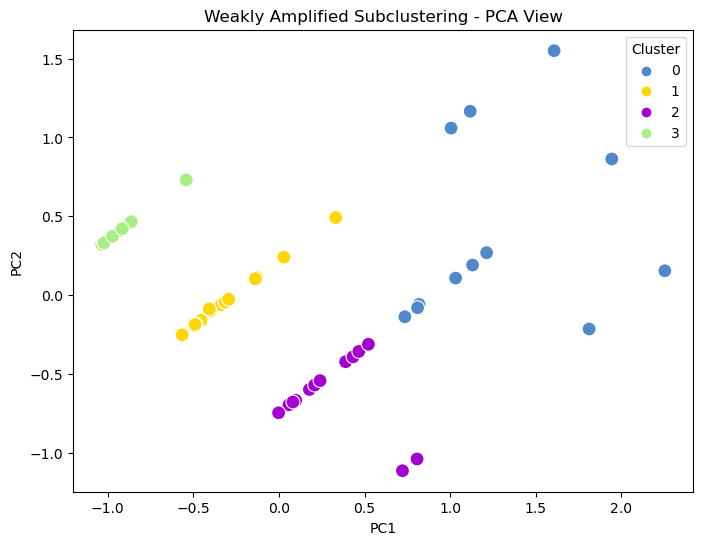

In [ ]:
features = ["size","reach","depth","width","speed"]
X_pca = PCA(n_components=2).fit_transform(viz_low[features])

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = viz_low["sub_cluster_low"].values

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Cluster", palette=["#5088cc", "#ffd700", "#a300cf", "#a8ed85"], s=100)

plt.title("Weakly Amplified Subclustering - PCA View")
plt.show()

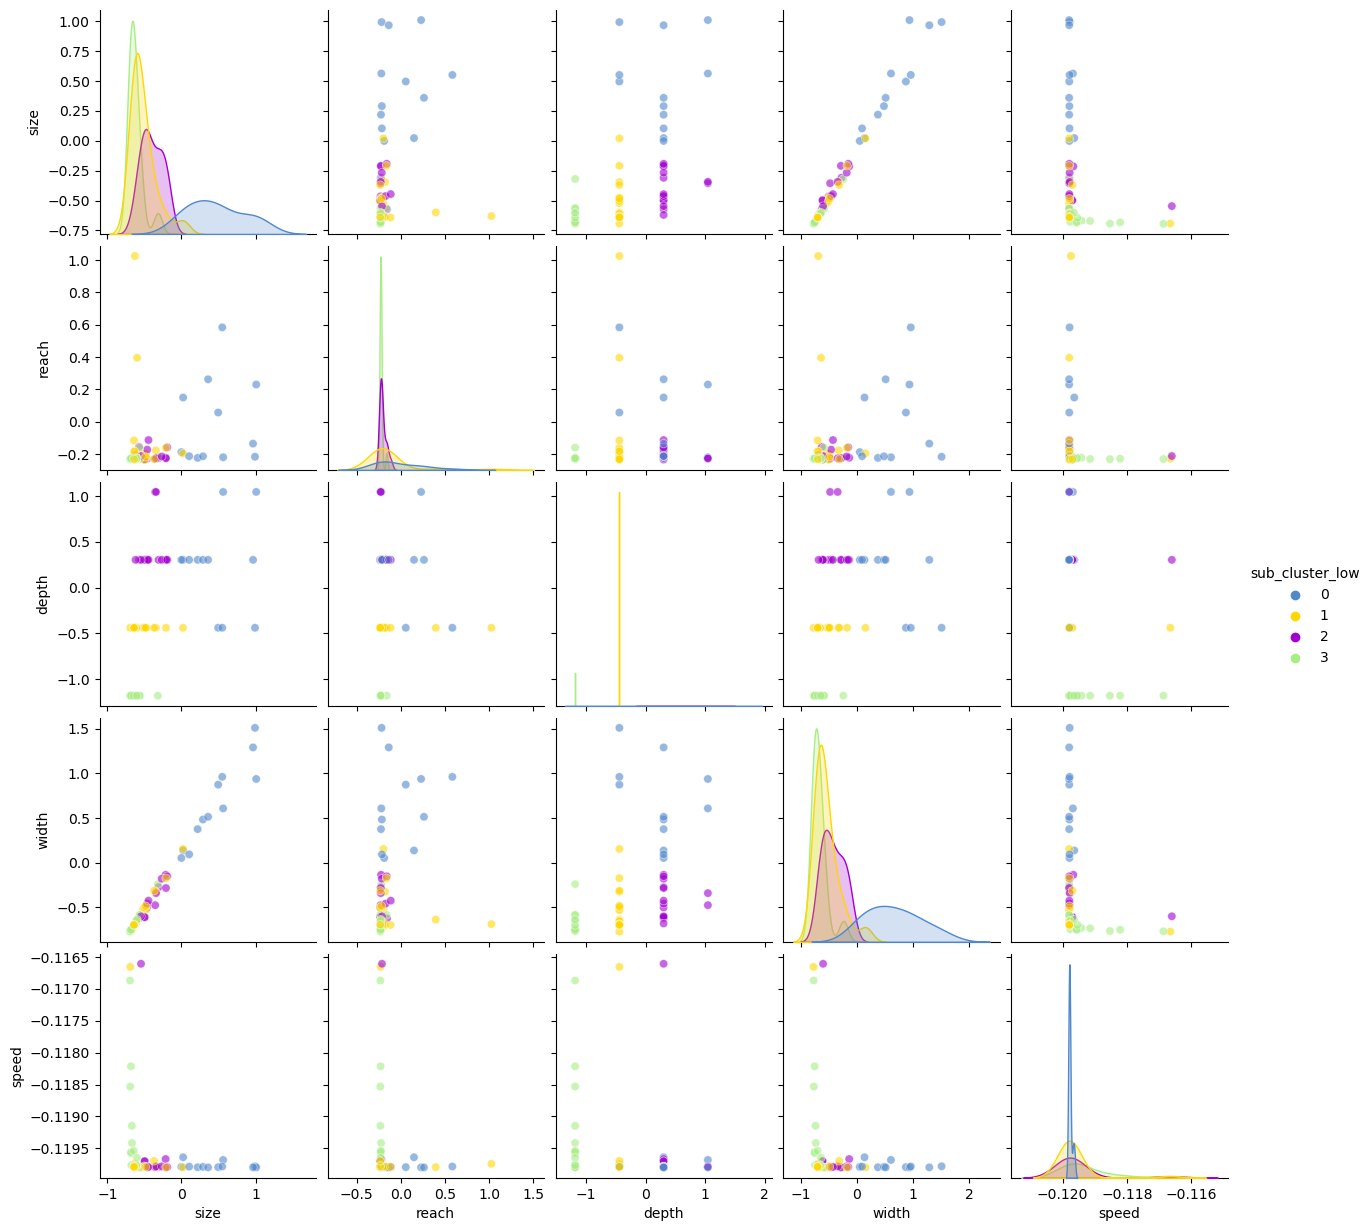

In [ ]:
import seaborn as sns

sns.pairplot(
    viz_low[features + ["sub_cluster_low"]],
    hue="sub_cluster_low",
    palette=["#5088cc", "#ffd700", "#a300cf", "#a8ed85"],
    diag_kind="kde",
    plot_kws={"alpha": 0.6}
)

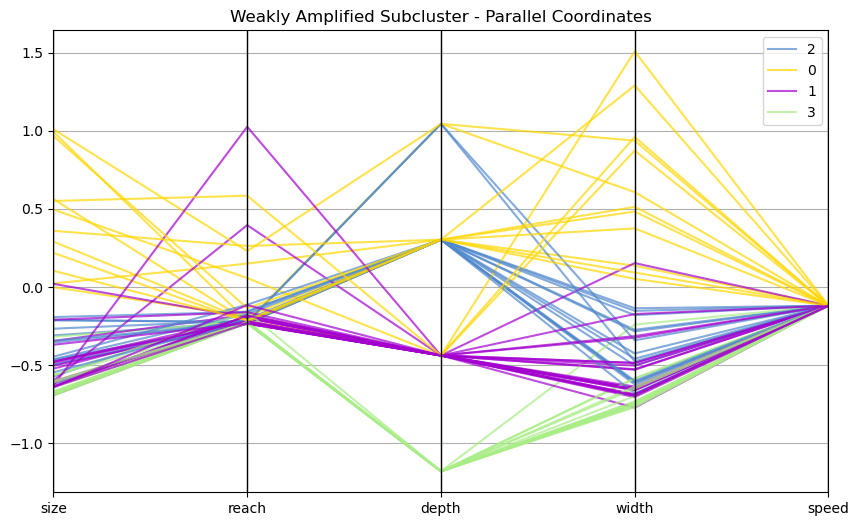

In [ ]:
from pandas.plotting import parallel_coordinates
import matplotlib.pyplot as plt

plot_df = viz_low[features + ["sub_cluster_low"]].copy()

plt.figure(figsize=(10,6))

parallel_coordinates(
    plot_df,
    class_column="sub_cluster_low",
    color=("#5088cc", "#ffd700", "#a300cf", "#a8ed85"),
    alpha=0.7
)

plt.title("Weakly Amplified Subcluster - Parallel Coordinates")
plt.show()